## 1. Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

# 1. Load dataset
df = pd.read_csv("Final_Dataset.csv", low_memory=False)

# 2. Temporal Harmonisation 
# Standardizing the timeline to a proper datetime format for time-series analysis
df["Date"] = pd.to_datetime(df["Year"].astype(str) + "-" + df["Month"].astype(str) + "-01")
df = df.sort_values("Date")

# 3. Handling Data Constraints 
# 'Target Rate' data is often missing in older records. To preserve 48 years of context,
# we create an 'Effective Policy Rate' using the 'Bank rate' as a proxy where 'Target rate' is NaN.
df['Effective_Policy_Rate'] = df['Target rate'].fillna(df['Bank rate'])

# 4. Standardizing Units for Comparison 
# Because units vary (e.g., % for rates vs. Millions for GDP), we must scale them 
# to ensure 'Analytical Use of Data' is appropriate and justifiable.
pestel_cols = [
    'Effective_Policy_Rate',     # Political
    'All industries [T001]',     # Economic
    'Unemployment rate',         # Social
    'Total traffic carried',     # Technological
    'Total softwood, production [24112]' # Environmental
]

scaler = StandardScaler()
df_scaled = df.copy()

# 5. We use a scaled dataframe for visualizations and comparisons
df_scaled[pestel_cols] = scaler.fit_transform(df[pestel_cols])

# 6. Descriptive Analysis Summary
sns.set_style("whitegrid")
print("Statistical Summary of Key PESTEL Indicators:")
df[pestel_cols].describe()

Statistical Summary of Key PESTEL Indicators:


,Effective_Policy_Rate,All industries [T001],Unemployment rate,Total traffic carried,"Total softwood, production [24112]"
count,788.000000,3.470000e+02,600.000000,3.230000e+02,143.000000
mean,5.455065,1.780726e+06,9.031848,1.840820e+07,1161.962300
std,3.953670,3.050244e+05,1.807004,2.280531e+06,242.274143
min,0.250000,1.200427e+06,5.572727,1.377132e+07,736.636364
25%,2.500000,1.548748e+06,7.834091,1.671285e+07,956.540909
50%,4.750000,1.749342e+06,8.577273,1.814211e+07,1151.490000
75%,8.000000,2.028334e+06,10.181818,2.034951e+07,1363.346970
max,21.025238,2.333959e+06,14.236364,2.323094e+07,1847.912500


## 2. Cleaning data

In [2]:
# 1. Standardize Infinity and Nulls
df = df.replace([np.inf, -np.inf], np.nan)

# 2. Strategic Proxy Creation 
df['Effective_Policy_Rate'] = df['Target rate'].fillna(df['Bank rate'])

# 3. Create a 'Modern Era' Analysis Subset
analysis_df = df[df['Year'] >= 1995].copy()

# 4. targeted Drop (Only for the analysis subset)
analysis_df = analysis_df.dropna(subset=["Effective_Policy_Rate", "Unemployment rate"])

# 5. Temporal Harmonization
analysis_df["Date"] = pd.to_datetime(analysis_df["Year"].astype(str) + "-" + analysis_df["Month"].astype(str) + "-01")
analysis_df = analysis_df.sort_values("Date")

print(f"Original Rows: {len(df)} | Rows preserved for analysis: {len(analysis_df)}")

Original Rows: 926 | Rows preserved for analysis: 372


# 3. Trend Analysis (Time Series)

## 3.1 Interest Rates Trend

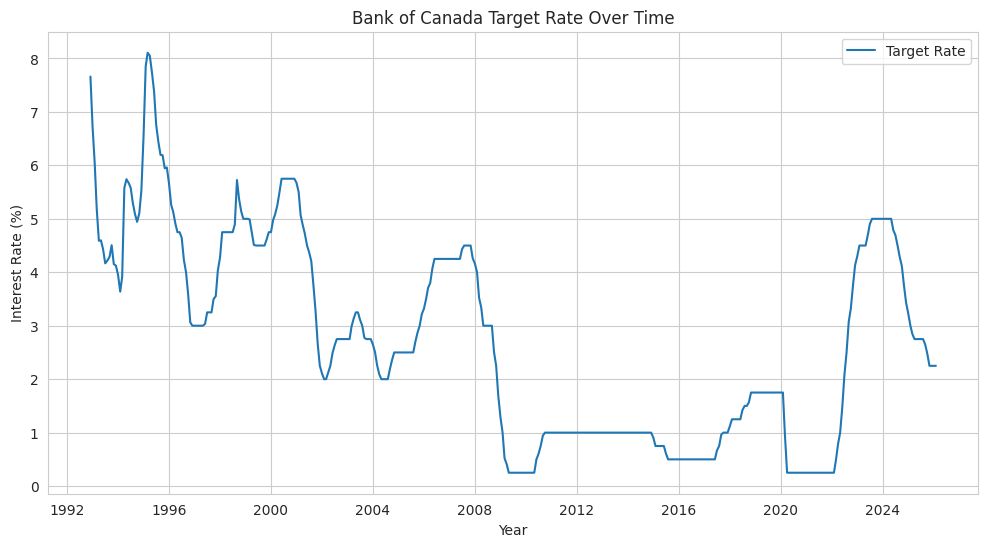

In [3]:
plt.figure(figsize=(12,6))
plt.plot(df["Date"], df["Target rate"], label="Target Rate")
plt.title("Bank of Canada Target Rate Over Time")
plt.xlabel("Year")
plt.ylabel("Interest Rate (%)")
plt.legend()
plt.show()

## 3.2 DGP trend

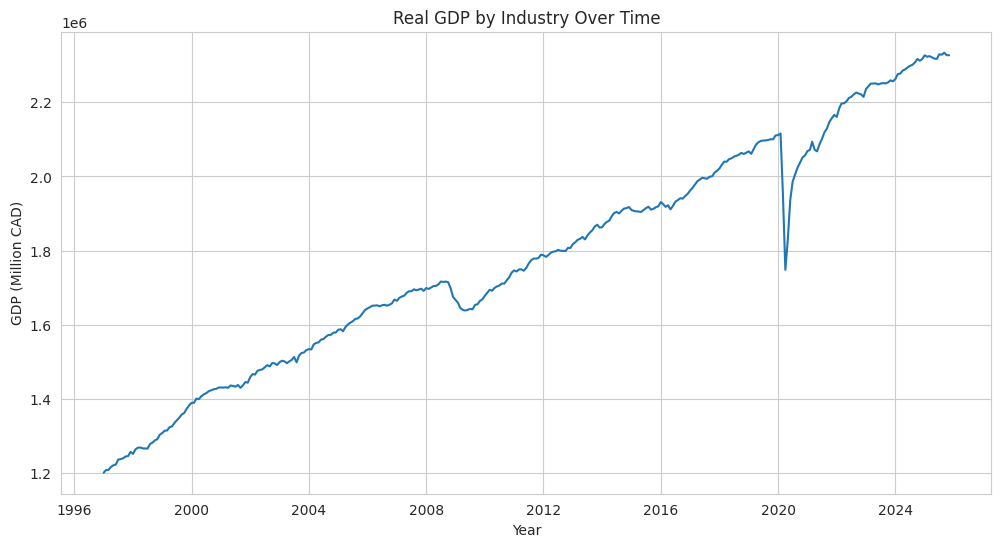

In [4]:
plt.figure(figsize=(12,6))
plt.plot(df["Date"], df["All industries [T001]"])
plt.title("Real GDP by Industry Over Time")
plt.xlabel("Year")
plt.ylabel("GDP (Million CAD)")
plt.show()

## 3.3 Unemployment Trend

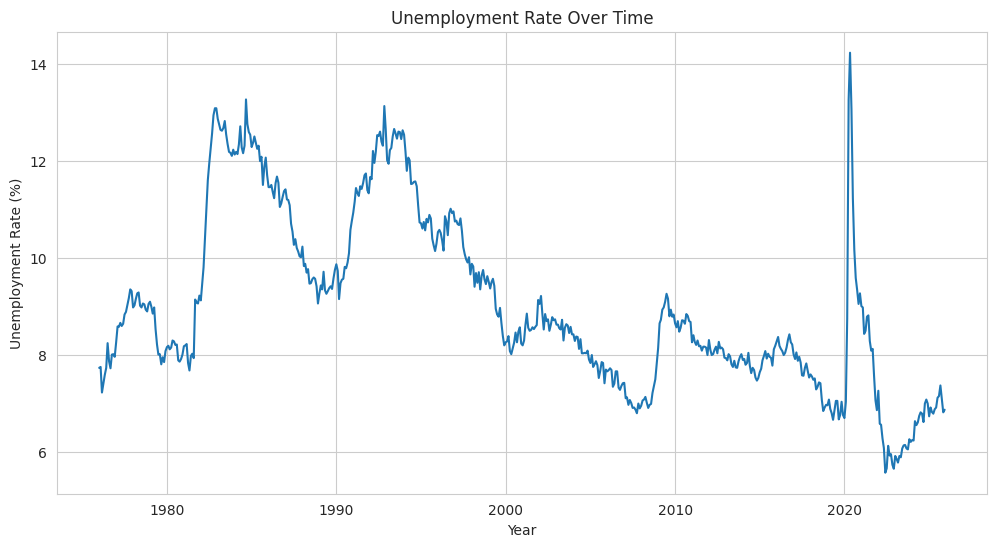

In [5]:
plt.figure(figsize=(12,6))
plt.plot(df["Date"], df["Unemployment rate"])
plt.title("Unemployment Rate Over Time")
plt.xlabel("Year")
plt.ylabel("Unemployment Rate (%)")
plt.show()

# 4. Statistical Analysis (Correlation)

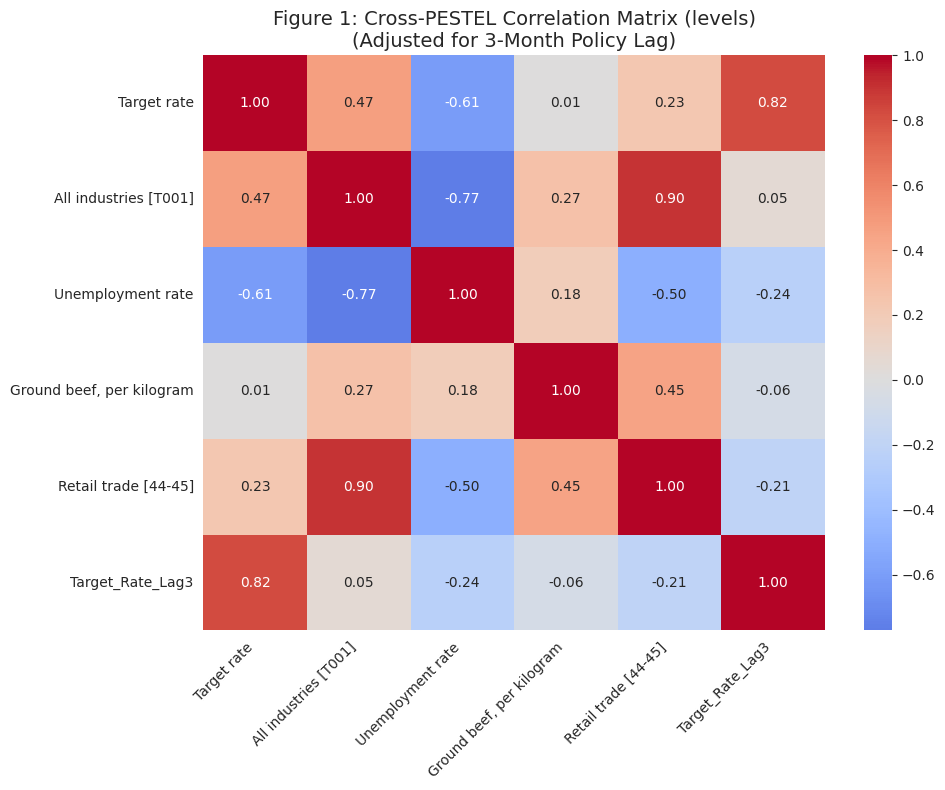

Key Insight: Notice how 'Target_Rate_Lag3' correlates differently with Unemployment than the current Target Rate.


In [6]:
# 1. Selection of Cross-Dimension Indicators
variables = [
    "Target rate", 
    "All industries [T001]", 
    "Unemployment rate", 
    "Ground beef, per kilogram", 
    "Retail trade [44-45]"
]

# 2. Add a 3-Month Lag for the Target Rate (Political Influence)
df['Target_Rate_Lag3'] = df['Target rate'].shift(3)
variables_with_lag = variables + ['Target_Rate_Lag3']

# 3. Filtering for a Clean Analysis Window
analysis_df = df[df['Year'] >= 2000].dropna(subset=variables_with_lag)

# 4. Calculate Correlation
corr = analysis_df[variables_with_lag].corr()

# 5. Professional Visualization for the Report
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", center=0)

plt.title("Figure 1: Cross-PESTEL Correlation Matrix (levels)\n(Adjusted for 3-Month Policy Lag)", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.savefig("pestel_correlation_matrix.png", dpi=300)
plt.show()

print("Key Insight: Notice how 'Target_Rate_Lag3' correlates differently with " 
      "Unemployment than the current Target Rate.")

### 4.1 Correlation of changes, not levels

Most of these series **trend over time**: GDP, food prices and retail sales all grow for decades. Two series that both trend upward will look strongly correlated even if they have nothing to do with each other (a *spurious correlation*).

A more reliable check is to correlate **year-over-year changes** (this month vs. the same month last year), which removes the long-term trend.

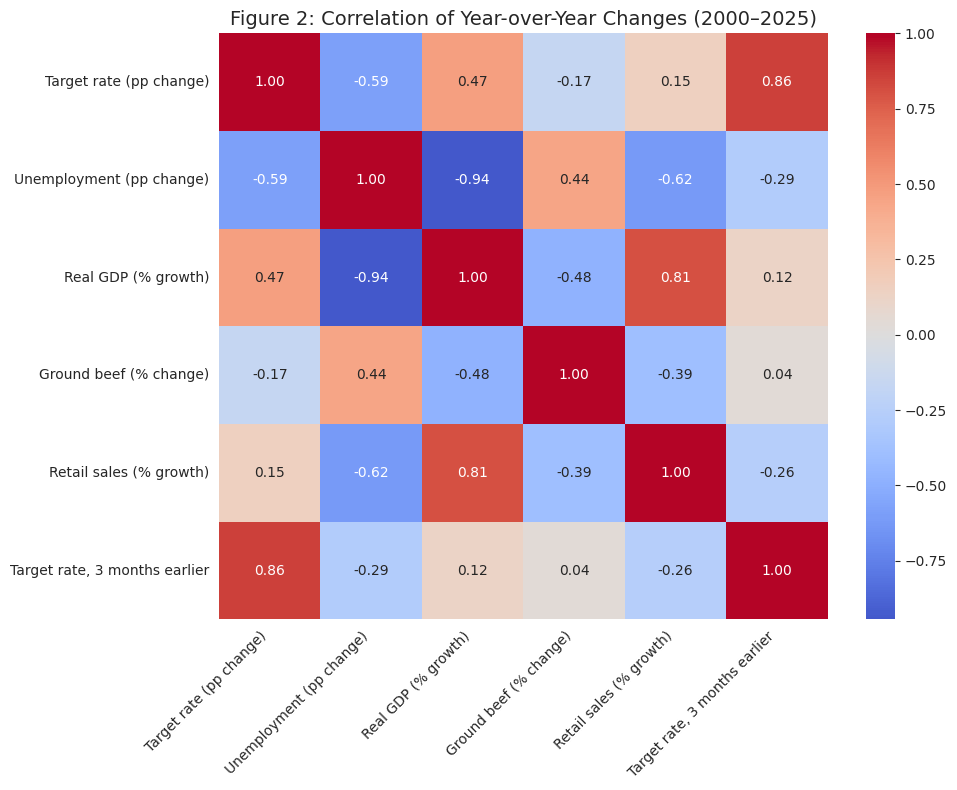

In [7]:
yoy_vars = ["Target rate", "All industries [T001]", "Unemployment rate",
            "Ground beef, per kilogram", "Retail trade [44-45]"]

yoy = df.set_index("Date")[yoy_vars].copy()
# Rates are already in %, so use the change in percentage points; for the others use % growth
yoy_change = pd.DataFrame({
    "Target rate (pp change)": yoy["Target rate"].diff(12),
    "Unemployment (pp change)": yoy["Unemployment rate"].diff(12),
    "Real GDP (% growth)": yoy["All industries [T001]"].pct_change(12, fill_method=None) * 100,
    "Ground beef (% change)": yoy["Ground beef, per kilogram"].pct_change(12, fill_method=None) * 100,
    "Retail sales (% growth)": yoy["Retail trade [44-45]"].pct_change(12, fill_method=None) * 100,
})
yoy_change["Target rate, 3 months earlier"] = yoy_change["Target rate (pp change)"].shift(3)
yoy_change = yoy_change[yoy_change.index.year >= 2000].dropna()

plt.figure(figsize=(10, 8))
sns.heatmap(yoy_change.corr(), annot=True, cmap="coolwarm", fmt=".2f", center=0)
plt.title("Figure 2: Correlation of Year-over-Year Changes (2000–2025)", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# 5. Environmental Impact Analysis

## 5.1 Lumber Production vs Interest Rates

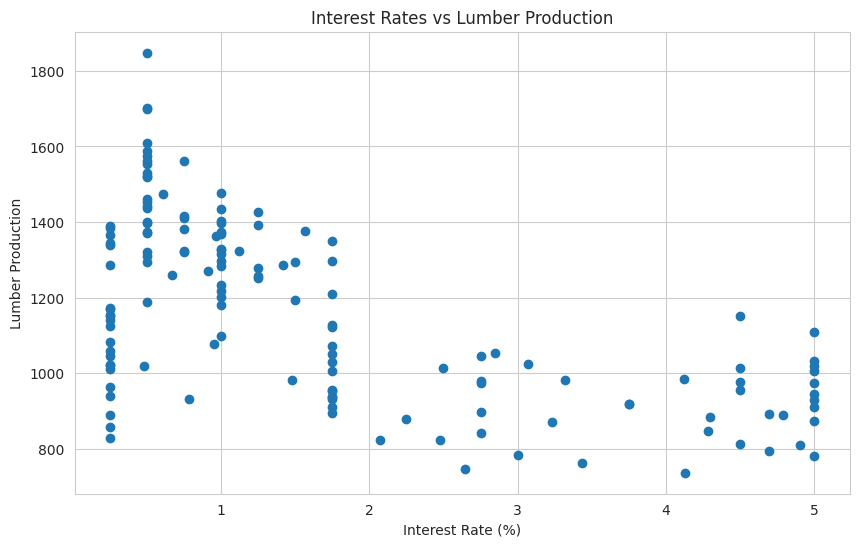

In [8]:
plt.figure(figsize=(10,6))
plt.scatter(df["Target rate"], df["Total softwood, production [24112]"])
plt.xlabel("Interest Rate (%)")
plt.ylabel("Lumber Production")
plt.title("Interest Rates vs Lumber Production")
plt.show()

## 5.2 Oil Production Trend

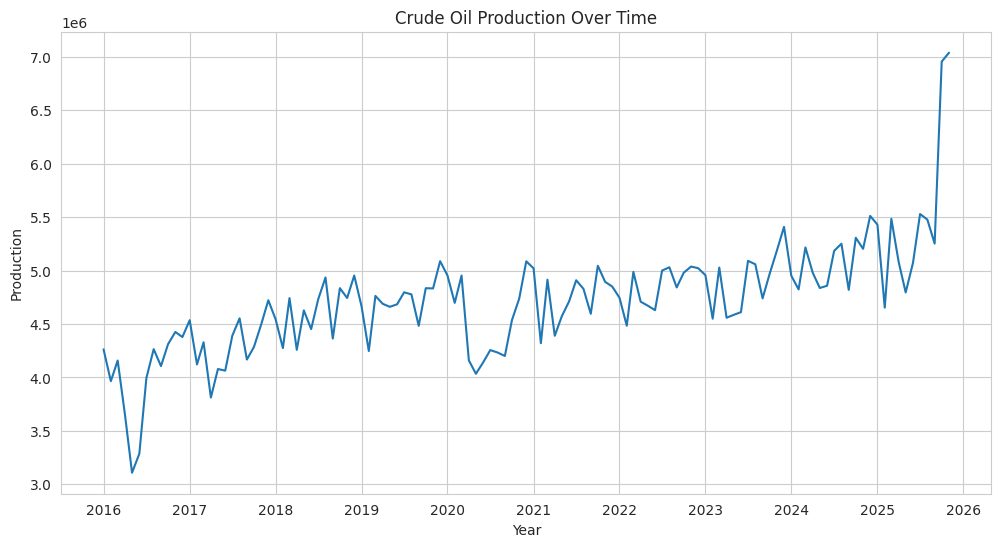

In [9]:
plt.figure(figsize=(12,6))
plt.plot(df["Date"], df["Crude oil production"])
plt.title("Crude Oil Production Over Time")
plt.xlabel("Year")
plt.ylabel("Production")
plt.show()

# 6. Transportation Leading Indicators

## 6.1 Aircraft Movements

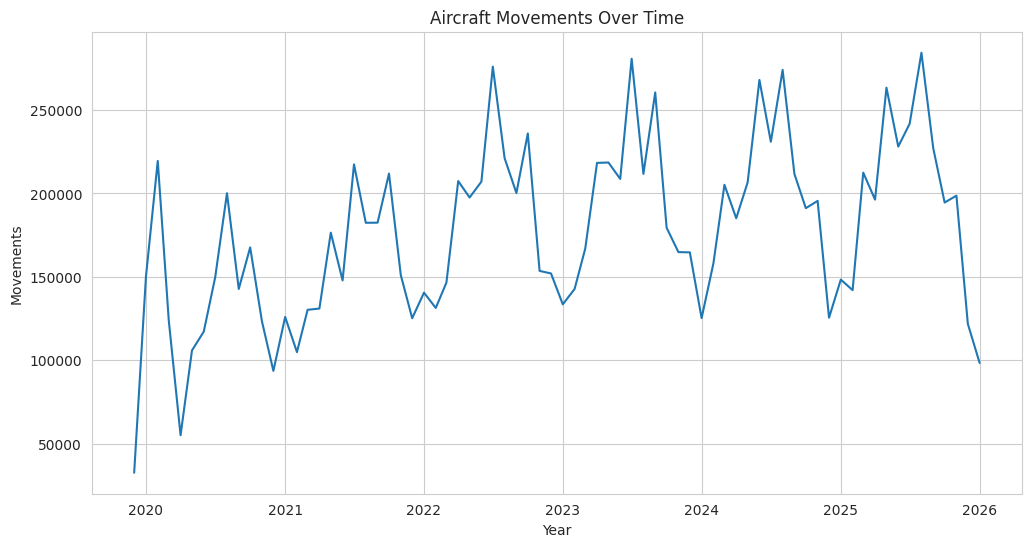

In [10]:
plt.figure(figsize=(12,6))
plt.plot(df["Date"], df["Domestic movements"])
plt.title("Aircraft Movements Over Time")
plt.xlabel("Year")
plt.ylabel("Movements")
plt.show()

## 6.2 Rail Traffic

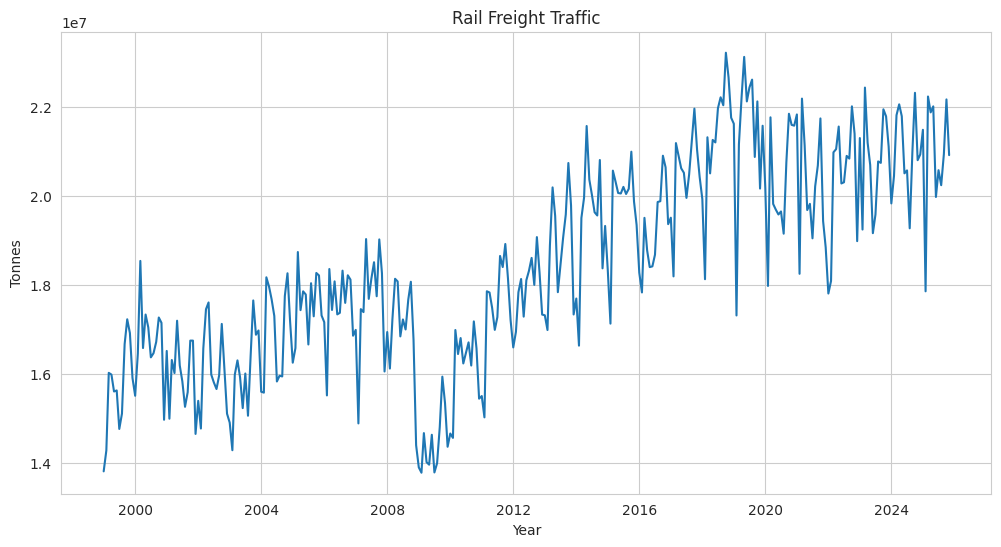

In [11]:
plt.figure(figsize=(12,6))
plt.plot(df["Date"], df["Total traffic carried"])
plt.title("Rail Freight Traffic")
plt.xlabel("Year")
plt.ylabel("Tonnes")
plt.show()

# 7. Regression

# 7. Regression

### 7.1 Original model: unemployment vs. the target rate 3 months earlier

This is the model from the first version of the analysis: OLS of the unemployment rate on the Bank of Canada target rate lagged 3 months, January 2000 onwards.

--- LAGGED REGRESSION RESULTS (3-MONTH DELAY) ---
                            OLS Regression Results                            
Dep. Variable:      Unemployment rate   R-squared:                       0.080
Model:                            OLS   Adj. R-squared:                  0.077
Method:                 Least Squares   F-statistic:                     26.93
Date:                Thu, 01 Oct 2026   Prob (F-statistic):           3.82e-07
Time:                        11:24:39   Log-Likelihood:                -436.94
No. Observations:                 312   AIC:                             877.9
Df Residuals:                     310   BIC:                             885.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------

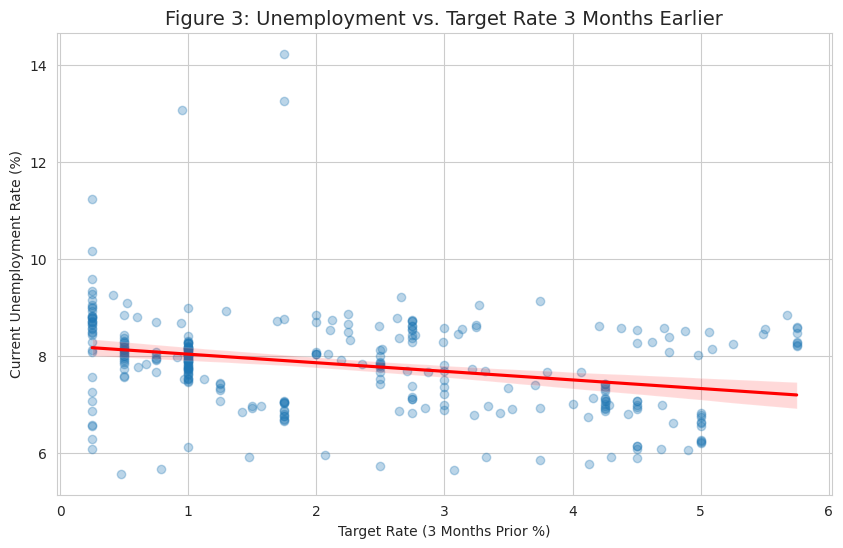

In [12]:
# 1. Create the lagged variable
df['Target_Rate_Lag3'] = df['Target rate'].shift(3)

# 2. Prepare data 
reg_df = df[df['Year'] >= 2000].dropna(subset=['Target_Rate_Lag3', 'Unemployment rate'])

# 3. Define Variables
X = reg_df[['Target_Rate_Lag3']] # Independent Variable
y = reg_df['Unemployment rate'] # Dependent Variable

# 4. Add constant and fit model
X = sm.add_constant(X)
model_lagged = sm.OLS(y, X).fit()

# 5. Output Summary
print("--- LAGGED REGRESSION RESULTS (3-MONTH DELAY) ---")
print(model_lagged.summary())

# 6. Visualization: Regression Plot
plt.figure(figsize=(10, 6))
sns.regplot(x='Target_Rate_Lag3', y='Unemployment rate', data=reg_df, 
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title("Figure 3: Unemployment vs. Target Rate 3 Months Earlier", fontsize=14)
plt.xlabel("Target Rate (3 Months Prior %)")
plt.ylabel("Current Unemployment Rate (%)")
plt.savefig("regression_analysis.png")
plt.show()

**Reading the output:**
- **Coefficient:** about **−0.18**. A 1-point higher target rate 3 months earlier goes with *lower* unemployment, the opposite of "rate hikes push unemployment up." The likely reason is **reverse causation**: the Bank raises rates when the economy is strong and unemployment is already low.
- **R²:** about **0.08**. The lagged rate explains only around 8% of the variation in unemployment.
- **Durbin-Watson:** about **0.14**. Values near 2 mean independent residuals, and values near 0 mean strong **autocorrelation**. That's expected in monthly data, where each month looks a lot like the last, but it breaks the assumption behind the standard p-value, so the reported significance is overstated.

### 7.2 Correcting for autocorrelation (Newey-West standard errors)

Newey-West (HAC) standard errors keep the same coefficient but give honest uncertainty when residuals are autocorrelated.

In [13]:
from statsmodels.stats.stattools import durbin_watson

model_hac = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 12})

print(f"Durbin-Watson statistic: {durbin_watson(model_lagged.resid):.2f}")
print()
print(pd.DataFrame({
    "Coefficient": [model_lagged.params["Target_Rate_Lag3"], model_hac.params["Target_Rate_Lag3"]],
    "p-value": [model_lagged.pvalues["Target_Rate_Lag3"], model_hac.pvalues["Target_Rate_Lag3"]],
}, index=["Standard OLS errors", "Newey-West (HAC) errors"]).round(4))

Durbin-Watson statistic: 0.14

                         Coefficient  p-value
Standard OLS errors          -0.1772   0.0000
Newey-West (HAC) errors      -0.1772   0.0814


### 7.3 Modelling changes instead of levels

A more meaningful question is: **when the Bank raises rates, does unemployment rise in the following months?** We regress the 12-month change in unemployment on the 12-month change in the target rate, lagged 3, 6 and 12 months, still using Newey-West errors.

In [14]:
results = []
for lag in [3, 6, 12]:
    data = pd.DataFrame({
        "unemployment_change": df.set_index("Date")["Unemployment rate"].diff(12),
        "rate_change_lagged": df.set_index("Date")["Target rate"].diff(12).shift(lag),
    })
    data = data[data.index.year >= 2000].dropna()

    m = sm.OLS(data["unemployment_change"], sm.add_constant(data["rate_change_lagged"])).fit(
        cov_type="HAC", cov_kwds={"maxlags": 12}
    )
    results.append({
        "Rate change lagged by": f"{lag} months",
        "Coefficient": m.params["rate_change_lagged"],
        "p-value (HAC)": m.pvalues["rate_change_lagged"],
        "R²": m.rsquared,
        "Observations": int(m.nobs),
    })

change_results = pd.DataFrame(results).set_index("Rate change lagged by")
change_results.round(3)

,Coefficient,p-value (HAC),R²,Observations
Rate change lagged by,,,,
3 months,-0.250,0.015,0.072,312
6 months,-0.103,0.307,0.012,312
12 months,0.134,0.223,0.019,312


### 7.4 Interpretation

- **No evidence that rate hikes raised unemployment within a year.** The only statistically significant relationship is at the **3-month lag, and it is negative** (about −0.25, p ≈ 0.015): rate increases tend to coincide with *falling* unemployment. At 6 and 12 months there is no significant relationship.
- **Rates explain very little of unemployment on their own.** R² stays below about 0.08 in every specification.
- **Policy rates respond to the economy as much as they shape it.** The negative short-lag relationship is consistent with the Bank raising rates when the labour market is strong. Separating cause from effect would need a model with more variables (inflation, GDP growth) and longer lags, such as a VAR model.

## 8. Comparative Trend Visualization

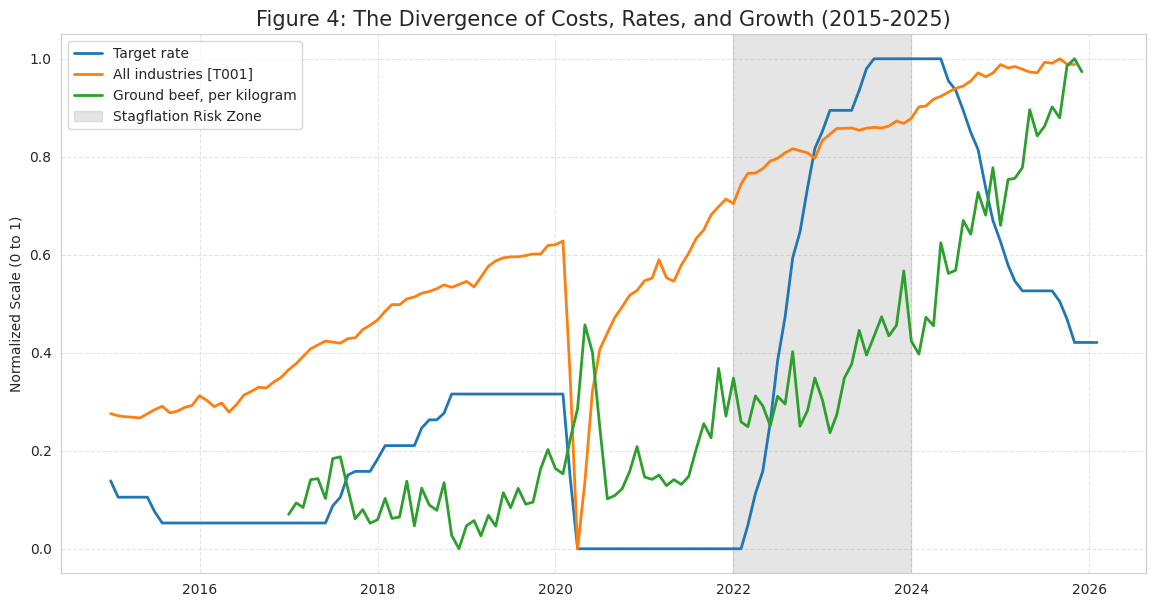

In [15]:
# 1. Normalize for comparison 
# We compare the 'Target Rate' against 'All industries GDP' and 'Ground beef' (Social/Cost of Living)
trend_vars = ["Target rate", "All industries [T001]", "Ground beef, per kilogram"]
df_trend = df[df['Year'] >= 2015].copy() # Focus on the recent crisis era

# 2. Plotting the 'Stagflation Gap'
plt.figure(figsize=(14, 7))

# We use the scaled versions to see the RELATIVE movement
for var in trend_vars:
    # Quick normalization: (x - min) / (max - min)
    val = df_trend[var]
    norm_val = (val - val.min()) / (val.max() - val.min())
    plt.plot(df_trend['Date'], norm_val, label=var, linewidth=2)

plt.axvspan('2022-01-01', '2024-01-01', color='gray', alpha=0.2, label='Stagflation Risk Zone')
plt.title("Figure 4: The Divergence of Costs, Rates, and Growth (2015-2025)", fontsize=15)
plt.ylabel("Normalized Scale (0 to 1)")
plt.legend(loc='upper left')
plt.grid(True, which='both', linestyle='--', alpha=0.5)

plt.savefig("stagflation_divergence.png")
plt.show()

## 9. Pattern Identification

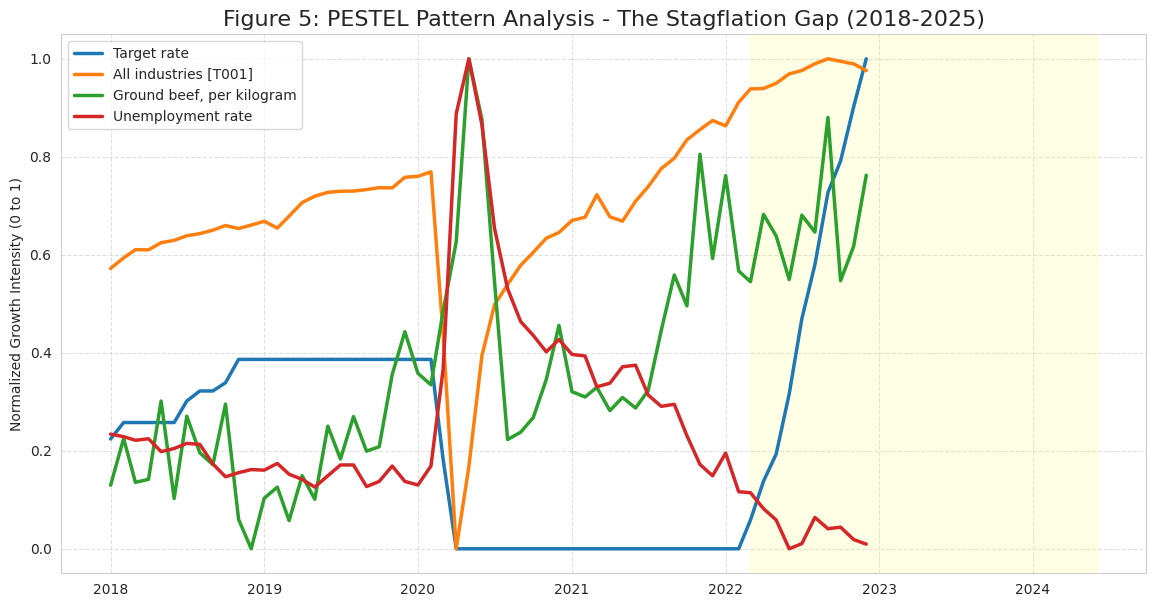

In [16]:
# 1. Select key indicators from different PESTEL dimensions
trend_vars = [
    "Target rate",               # Political
    "All industries [T001]",     # Economic
    "Ground beef, per kilogram", # Social (Cost of Living)
    "Unemployment rate"          # Social (Economic Health)
]

# 2. Filter for the recent "Crisis Era" (2018 - 2025)
df_recent = analysis_df[analysis_df['Year'] >= 2018].copy()

# 3. Min-Max Normalization for visual comparison
# This scales everything between 0 and 1 so we can see the relative "speed" of change.
df_norm = df_recent.copy()
for var in trend_vars:
    df_norm[var] = (df_recent[var] - df_recent[var].min()) / (df_recent[var].max() - df_recent[var].min())

# 4. Plotting the patterns
plt.figure(figsize=(14, 7))
for var in trend_vars:
    plt.plot(df_norm['Date'], df_norm[var], label=var, linewidth=2.5)

plt.title("Figure 5: PESTEL Pattern Analysis - The Stagflation Gap (2018-2025)", fontsize=16)
plt.ylabel("Normalized Growth Intensity (0 to 1)")
plt.legend(frameon=True, loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)

# Shading the period of aggressive rate hikes
plt.axvspan('2022-03-01', '2024-06-01', color='yellow', alpha=0.1, label='Aggressive Tightening')

plt.savefig("stagflation_pattern.png", dpi=300)
plt.show()

## 10. Conclusion

**What the data supports**
- From 2022 onward the conditions for **stagflation risk** did appear together. The average target rate rose from 0.25% (2021) to about 4.7% (2023–2024), real GDP growth slowed from about 4.7% (2022) to about 2% (2023–2024) and 1.3% (2025), and ground beef prices rose 7–17% per year from 2022 to 2025. Unemployment also edged up from about 6.0% (2023) to 7.0% (2025).
- The merged dataset brings 15 Statistics Canada sources into one monthly timeline, which makes these cross-dimension comparisons possible.

**What the data does *not* support**
- The first version of this analysis concluded that rate hikes had a *"statistically significant, delayed impact"* on unemployment. After correcting for autocorrelation and modelling changes instead of levels, the levels model is **not statistically significant** (p ≈ 0.08), and the only significant short-lag relationship in the change model is **negative**, the opposite of the original claim.
- Correlations between trending series in levels (Figure 1) overstate relationships. The year-over-year correlations (Figure 2) are a better guide.

**Next steps**
- Add inflation (CPI) and GDP growth to the model and use a VAR or distributed-lag model to study effects over 12–24 months.
- Define a formal stagflation indicator (for example, CPI inflation above 3% while real GDP growth is below 1%) and test which months meet it.

**Lesson learned:** a tiny p-value doesn't mean much if the model's assumptions are broken. With time-series data, always check residual autocorrelation before trusting significance tests.